In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

# Evaluation Metrics

Function that compares the predictions with the actual values and outputs a single number that tells how good the predictions are.

## Recap: load and train the model for the lecture

In [2]:
df = pd.read_csv('data-week-3.csv')
df.columns = df.columns.str.lower().str.replace(' ','_')
categorical_cols = list(df.dtypes[df.dtypes == 'object'].index)
categorical_cols += list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_cols:
    df[c] = df[c].str.lower().str.replace(' ','_')
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn=='yes').astype(int)

In [3]:
df_full_train, df_test = train_test_split(df, test_size = 0.2, random_state = 42)
df_train, df_val = train_test_split(df_full_train, test_size = 0.25, random_state = 42)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn
y_val = df_val.churn
y_test = df_test.churn

del df_train['churn']
del df_val['churn']
del df_test['churn']

In [4]:
num_f = ['tenure', 'monthlycharges', 'totalcharges']
cat_f = ['gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',]

In [5]:
dv = DictVectorizer(sparse=False)

X_train_num = df_train[num_f].values
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num)

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_cat = df_train[cat_f].values

X_train_cat = ohe.fit_transform(X_train_cat)

X_train = np.column_stack([X_train_num, X_train_cat])

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [6]:
X_val_num = df_val[num_f].values
X_val_num = scaler.transform(X_val_num)
X_val_cat = ohe.transform(df_val[cat_f].values)

X_val = np.column_stack([X_val_num, X_val_cat])

In [7]:
y_pred = model.predict_proba(X_val)[:,1]
churn_decision = (y_pred >= 0.5).astype(int)

In [8]:
(y_val == churn_decision).mean()

np.float64(0.8026969481902059)

# Accuracy and dummy model

## Accuracy

Measures the fraction of correct predictions: the number of correct predictions divided by the total number of predictions.

In [9]:
len(y_val)

1409

In [10]:
(y_val == churn_decision).mean()

np.float64(0.8026969481902059)

1123/1049 is 80%

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy_score(y_val, churn_decision)

0.8026969481902059

the 0.5 threshold was a guess. The model outputs a probability, and we can announce churn for any cutoff we like.

In [12]:
thresholds = np.linspace(0,1,21)

scores = []

for t in thresholds:
    score = accuracy_score(y_val, (y_pred >= t).astype(int))
    print('%.2f %.3f' % (t, score))
    scores.append(score)

0.00 0.269
0.05 0.539
0.10 0.615
0.15 0.665
0.20 0.698
0.25 0.742
0.30 0.760
0.35 0.776
0.40 0.783
0.45 0.794
0.50 0.803
0.55 0.801
0.60 0.786
0.65 0.776
0.70 0.764
0.75 0.740
0.80 0.735
0.85 0.731
0.90 0.731
0.95 0.731
1.00 0.731


<Axes: >

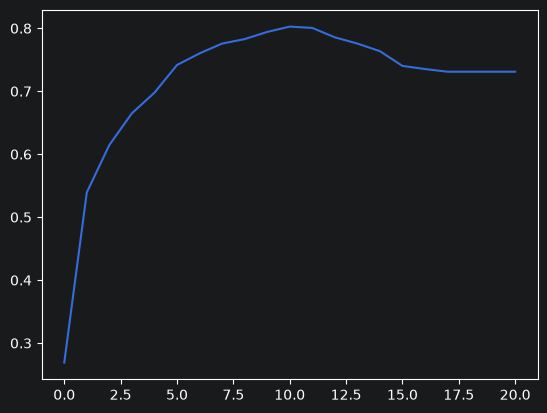

In [13]:
sns.lineplot(scores)

So for this decision cutoff is 0.5, with 80% accuracy. On other problems the best threshold is often different.

## The dummy model

What if we don't use a model at all, and simply predict that no customer will ever churn? that is the same as setting the threshold as 1.0.

In [14]:
from collections import Counter

Counter(y_pred >= 1.0)

Counter({np.False_: 1409})

In [15]:
1-y_val.mean()

np.float64(0.7310149041873669)

So a model that does not look at the data at all scores 73%, and our logistic scores 80%. The improvement over dummy baseline is much smaller.

## Why accuracy fails: class imbalance

The reason is that classes are unbalanced: only 27% of the customers in the validation set churned, and 73% stayed. This is class imbalance: there are many more instances of one class than of the other.
With such an imbalance, a model can get a high accuracy by always predicting the majority class, while being completely useless for the minority class, which is exactly the class we care about: we want to find the customers who are about to leave.
For this problem accuracy alone cannot tell us how good the model is. We need metrics that look at the errors in more detail.

# Confusion Table

Accuracy collapses all predictions into a single number, so it cannot tell us which kinds of mistakes the model makes. In this lesson we look at the confusion table: a way of measuring the different types of errors and correct decisions a binary can make, arranged in one table

| Prediction      | Actual      | Name |
| ------------- | ------------- | ---- |
| Customer will churn (pos) | Churned | True Positive(TP) |
| Customer will churn (pos) | Did not churn| False Positive(FP)|
| Customer will not churn(neg) | Churned | False Negative(FN) |
| Customer will not churn(neg) | Did not churn | True Negative(TN) |

A false positive is a customer we sent a promotional email to, but who was never going to leave. A flase negative is a customer who left without us ever flagging them.

In [16]:
actual_pos = (y_val == 1)
actual_neg = (y_val==0)

t = 0.5
pred_pos = (y_pred >= t)
pred_neg = (y_pred < t)

In [17]:
tp = (pred_pos & actual_pos).sum()
tn = (pred_neg & actual_neg).sum()

fp = (pred_pos & actual_neg).sum()
fn = (pred_neg & actual_pos).sum()

In [18]:
confusion_matrix = np.array([
    [tn,tp],
    [fn,fp],
])
confusion_matrix

array([[928, 203],
       [176, 102]])

In [19]:
(confusion_matrix / confusion_matrix.sum()).round(2)

array([[0.66, 0.14],
       [0.12, 0.07]])

Accuracy is the sum of the diagonal, divided by the total.

# Precision and Recall

Precision and recall are the two metrics that look at each kind of mistakes separately: they both focus on the positive class, and see problems that accuracy hides.

## Precision

Tells us the fraction of positive predictions that are correct. It looks only at the customer we predicted to churn, the positive column of the confusion table (TP and FP):
$P = \frac{TP}{TP+FP}$

In [20]:
p = tp / (tp+fp)
p

np.float64(0.6655737704918033)

## Recall

Measures the fraction of actual positive instances that we identified correctly. The positive row of the confusion table (TP and FN):
$R = \frac{TP}{TP+FN}$

In [21]:
r = tp / (tp+fn)
r

np.float64(0.5356200527704486)

Precision and recall explain where the model actually stands. These numbers reflect the errors of our model that accuracy did not notice because of class imbalance. When classes are imbalanced, precision and recall are the metrics to look at.

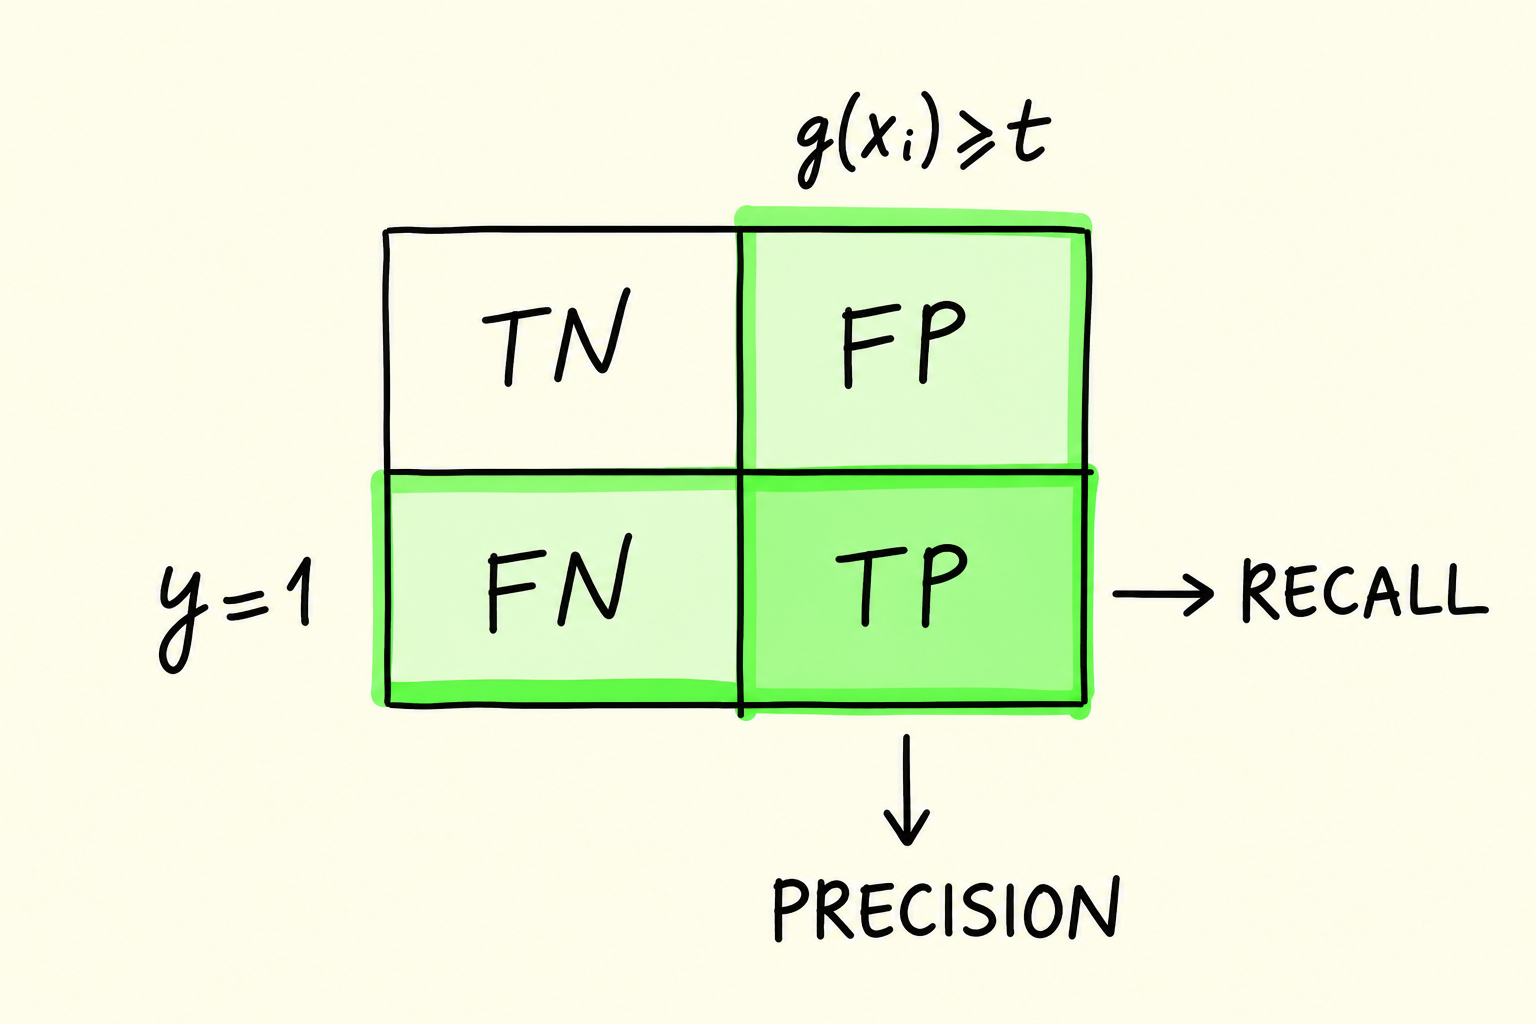

# ROC Curves

Precision and recall look at the model at on fixed threshold. A ROC curve looks at all possible thresholds at once, which makes it a way to evaluate the performance of a binary classifier over its whole range of operating points. ROC stands for Receiver Operating Characteristic, the idea comes from WW2, where it was used to evaluate the strength of radio detectors.

## TPR and FPR

The ROC curve is build from two rates derived from the confusion table. The true positive rate (TPR) is the fraction of actual positives we identified correctly, same thing as recall: TP divided by all pos observations. This is a metric we want to maximize.

$TPR = \frac{TP}{TP+FN}$

The false positive rate (FPR) is the fraction of actual negatives we got wrong: FP divided by all negative observations. This is a metric we want to minimize.

$FPR = \frac{FP}{TN+FP}$

In [22]:
tpr = tp /(tp+fn)
fpr = fp /(tn+fp)

In [23]:
tpr, fpr

(np.float64(0.5356200527704486), np.float64(0.09902912621359224))

These two numbers describe the model at one threshold. Let's compute them for many thresholds.

In [24]:
scores = []

thresholds = np.linspace(0,1,101)

for t in thresholds:
    actual_pos = (y_val == 1)
    actual_neg = (y_val == 0)

    pred_pos = (y_pred >= t)
    pred_neg = (y_pred < t)

    tp = (pred_pos & actual_pos).sum()
    tn = (pred_neg & actual_neg).sum()

    fp = (pred_pos & actual_neg).sum()
    fn = (pred_neg & actual_pos).sum()

    scores.append((t, tp, tn, fp, fn))

columns = ['thresholds', 'tp', 'tn', 'fp', 'fn']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

Plotting both rates against the threshold shows how the trade-off shifts: as the threshold grows, we flag fewer customers, so both the tpr and fpr rate fall:

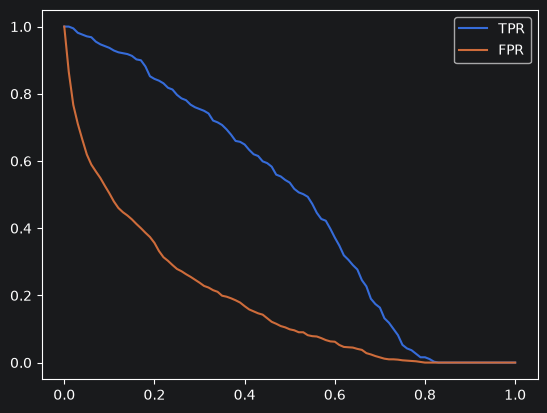

In [25]:
plt.plot(df_scores.thresholds, df_scores['tpr'], label='TPR')
plt.plot(df_scores.thresholds, df_scores['fpr'], label='FPR')
plt.legend()

To read this curve we need points of reference. The first one: a model that outputs random scores. We generate a uniform random score for every customer:

In [26]:
np.random.seed(1)
y_rand = np.random.uniform(0,1,size=len(y_val))

In [27]:
scores = []

thresholds = np.linspace(0,1,101)

for t in thresholds:
    actual_pos = (y_val == 1)
    actual_neg = (y_val == 0)

    pred_pos = (y_rand >= t)
    pred_neg = (y_rand < t)

    tp = (pred_pos & actual_pos).sum()
    tn = (pred_neg & actual_neg).sum()

    fp = (pred_pos & actual_neg).sum()
    fn = (pred_neg & actual_pos).sum()

    scores.append((t, tp, tn, fp, fn))

columns = ['thresholds', 'tp', 'tn', 'fp', 'fn']
df_rnd = pd.DataFrame(scores, columns=columns)

df_rnd['tpr'] = df_rnd.tp / (df_rnd.tp + df_rnd.fn)
df_rnd['fpr'] = df_rnd.fp / (df_rnd.fp + df_rnd.tn)

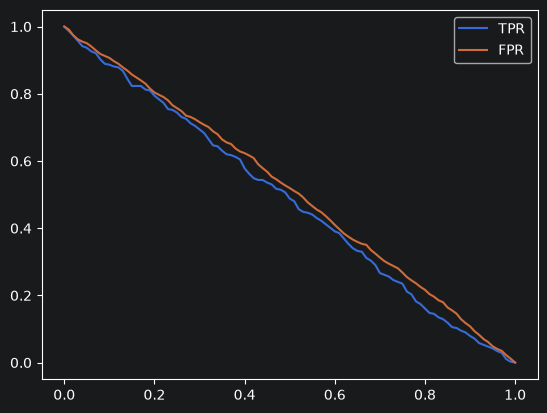

In [28]:
plt.plot(df_rnd.thresholds, df_rnd['tpr'], label='TPR')
plt.plot(df_rnd.thresholds, df_rnd['fpr'], label='FPR')
plt.legend()

Accuracy at threshold 0.5 is 50%, a coin flip. Computing TPR/FPR table for these random scores and plotting two almost straigth lines going down together. For the random model, at any threshold the fraction of positives we catch is the same as the fraction of negatives, cannot tell the two groups apart.

The second reference: an ideal model that ranks all customers perfectly. build it by hand: sort customers and give them scores evenly spread from 0 to 1:

In [29]:
num_neg = (y_val == 0).sum()
num_pos = (y_val == 1).sum()

y_ideal = np.repeat([0,1], [num_neg, num_pos])
y_ideal_pred = np.linspace(0,1,len(y_val))

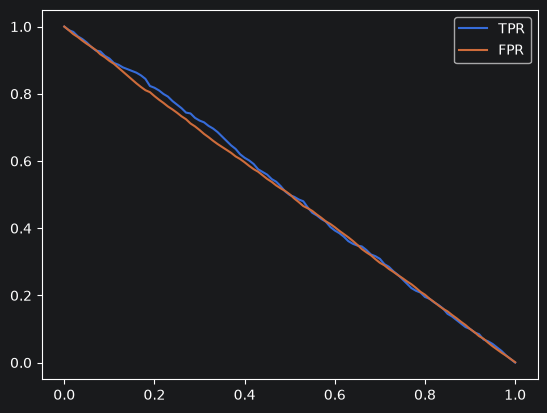

In [30]:
scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_pos = (y_val == 1)
    actual_neg = (y_val == 0)

    pred_pos = (y_ideal_pred >= t)
    pred_neg = (y_ideal_pred < t)

    tp = (pred_pos & actual_pos).sum()
    tn = (pred_neg & actual_neg).sum()

    fp = (pred_pos & actual_neg).sum()
    fn = (pred_neg & actual_pos).sum()

    scores.append((t, tp, tn, fp, fn))

columns = ['thresholds', 'tp', 'tn', 'fp', 'fn']
df_ideal = pd.DataFrame(scores, columns=columns)

df_ideal['tpr'] = df_ideal.tp / (df_ideal.tp + df_ideal.fn)
df_ideal['fpr'] = df_ideal.fp / (df_ideal.fp + df_ideal.tn)
plt.plot(df_ideal.thresholds, df_ideal['tpr'], label='TPR')
plt.plot(df_ideal.thresholds, df_ideal['fpr'], label='FPR')
plt.legend()

In [31]:
accuracy_score(y_ideal, y_ideal_pred>= 0.726)

0.9950319375443577

Plotting our model together with the ideal one makes the comparison obvious: the black TPR cure of our model is clearly below the ideal and the blue FPR curve above the ideal, the gap between them is the room our model still has to improve.

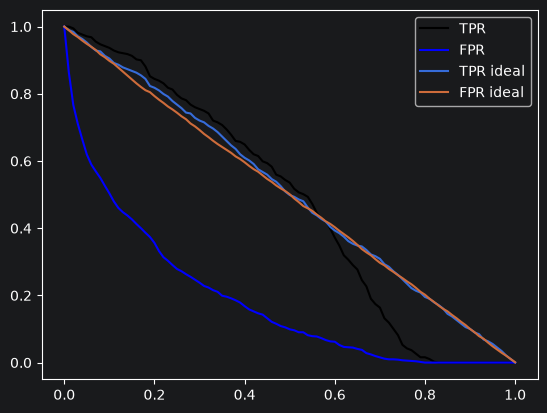

In [32]:
plt.plot(df_scores.thresholds, df_scores['tpr'], label='TPR', color='black')
plt.plot(df_scores.thresholds, df_scores['fpr'], label='FPR', color='blue')

plt.plot(df_ideal.thresholds, df_ideal['tpr'], label='TPR ideal')
plt.plot(df_ideal.thresholds, df_ideal['fpr'], label='FPR ideal')

plt.legend()

## The ROC curve

The ROC curve itself plots TPR against FPR, not against the threshold. Each point on the curve is the model operating at one threshold: the bottom-left corner is a conservative model, the top-right corner flags everybody. We plot our model against the random one, which becomes the diagonal line.

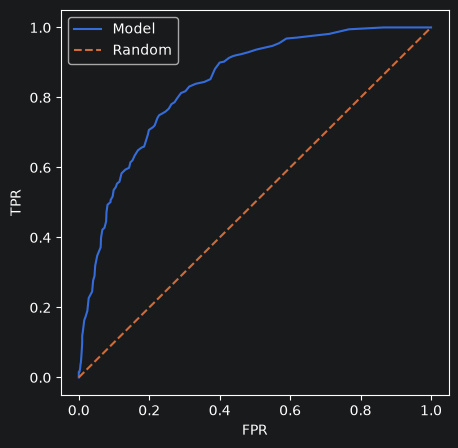

In [33]:
plt.figure(figsize=(5, 5))

plt.plot(df_scores.fpr, df_scores.tpr, label='Model')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

The closer the curve hugs the top-left corner, high true positive rate at a low false positive rate, the better the model. A curve sitting on the diagonal belongs to a random model.

In [34]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

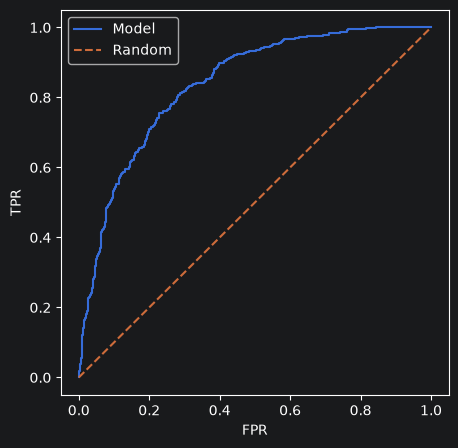

In [35]:
plt.figure(figsize=(5, 5))

plt.plot(fpr, tpr, label='Model')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

# ROC AUC

A curve is a picture not a number. Compressing the ROC curve into a single metric, the area under the ROC curve, ROC AUC or just AUC, and then look at a very useful interpretation of what that number actually means.

## Area under ROC curve

The AUC of a model is the area under this curve:
The interpretation of the reference points follows straight from the shape of the curve
<lo>
<li> The ideal model covers the whole square above the diagonal, so its AUC is 1.
<li> The random model sits on the diagonal and covers only the triangle below it, so its AUC is 0.5.
<lo>

A real model lands between 0.5 and 1: the closer its curve is to the top left-corner, the larger the area under it. As a rule of thumb, an AUC around 0.8 is good, 0.9 is great, and 0.6 is poor

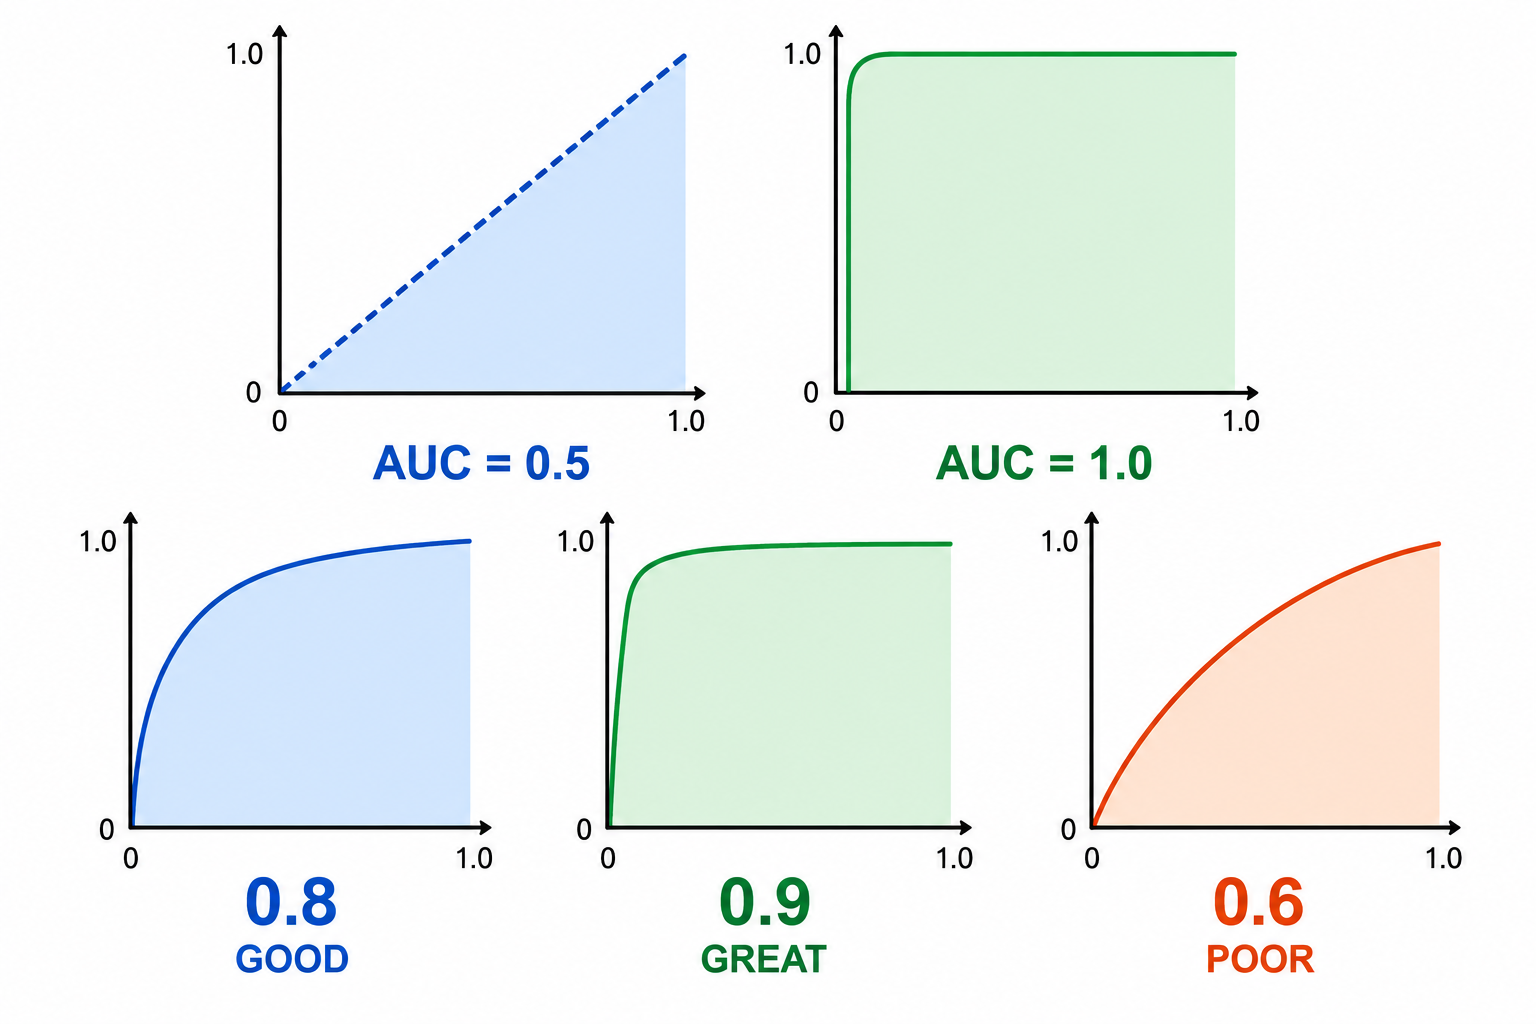

In [36]:
from sklearn.metrics import auc
auc(fpr, tpr)

0.8376950073007658

In [37]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_val, y_pred)

0.8376950073007658

## Interpreting AUC

AUC has a second, probabilistic interpretation that makes it very intuitive: AUC is the probability that a randomly selected positive example has a greater score than a randomly selected negative example.

In [38]:
neg = y_pred[y_val == 0]
pos = y_pred[y_val == 1]

In [39]:
import random

n = 100000
success = 0

for i in range(n):
    pos_ind = random.randint(0, len(pos)-1)
    neg_ind = random.randint(0, len(neg)-1)

    if pos[pos_ind] > neg[neg_ind]:
        success += 1

success / n

0.83728

In [40]:
n = 5000
np.random.seed(1)
pos_ind = np.random.randint(0, len(pos)-1, size=n)
neg_ind = np.random.randint(0, len(neg)-1, size=n)

(pos[pos_ind] > neg[neg_ind]).mean()

np.float64(0.8264)

AUC is a popular metric for binary classification: it says how well the model separates the two classes, and it does not depend on the class balance or on any particualar threshold

# Cross-Validation

Way to evaluate the same model on different subsets of the data, so we get not just one number but an average and a spread, and we can use it for parameter tuning: selecting the best params for the model.

In [62]:
def train(df_train, y_train, C=1.0):

    X_train_num = df_train[num_f].values
    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train_num)

    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

    X_train_cat = df_train[cat_f].values

    X_train_cat = ohe.fit_transform(X_train_cat)

    X_train = np.column_stack([X_train_num, X_train_cat])

    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train, y_train)

    return scaler, ohe, model

In [63]:
def predict(df, scaler, ohe, model):
    df_num = df[num_f].values
    df_cat = df[cat_f].values
    df_num = scaler.transform(df_num)
    df_cat = ohe.transform(df_cat)


    X = np.column_stack([df_num, df_cat])
    y_pred = model.predict_proba(X)[:,1]
    return y_pred

## K-fold cross-validation

Split the full training dataset into k partitions(folds). Train the model on k-1 folds, evaluate on the remaining one. Repeat k times, so every fold serves as the validation set once, and average the scores.

In [64]:
from sklearn.model_selection import KFold

In [65]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

In [66]:
from tqdm.auto import tqdm

In [68]:
n_splits = 5

for C  in tqdm([0.001,0.01,0.1,0.5,1,5,10]):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.churn.values
        y_val = df_val.churn.values

        scaler, ohe,model=train(df_train, y_train, C=C)
        y_pred = predict(df_val, scaler, ohe, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

 29%|██▊       | 2/7 [00:00<00:00, 12.28it/s]

C=0.001 0.832 +- 0.007
C=0.01 0.837 +- 0.007
C=0.1 0.840 +- 0.006


 86%|████████▌ | 6/7 [00:00<00:00, 11.49it/s]

C=0.5 0.840 +- 0.006
C=1 0.840 +- 0.006
C=5 0.841 +- 0.006


100%|██████████| 7/7 [00:00<00:00, 11.27it/s]

C=10 0.841 +- 0.006


In [69]:
scores

[0.8352668776969099,
 0.8461123195258811,
 0.8380067277236232,
 0.848726835021731,
 0.834387811295356]

In [71]:
scaler,ohe, model = train(df_full_train, df_full_train.churn.values, C=1.0)
y_pred = predict(df_test, scaler,ohe, model)

auc = roc_auc_score(y_test, y_pred)
auc

0.8622912935915618

## When to use cross-validation

<lo>
<li> If the dataset is large, a single hold-out validation split is usually enough, is faster and the estimate is already stable
<li> If the dataset is small, or we want to know how stable the model is across different splits, cross-val is worth the extra computation. More folds give a better estimate but take longer to compute.
<lo>

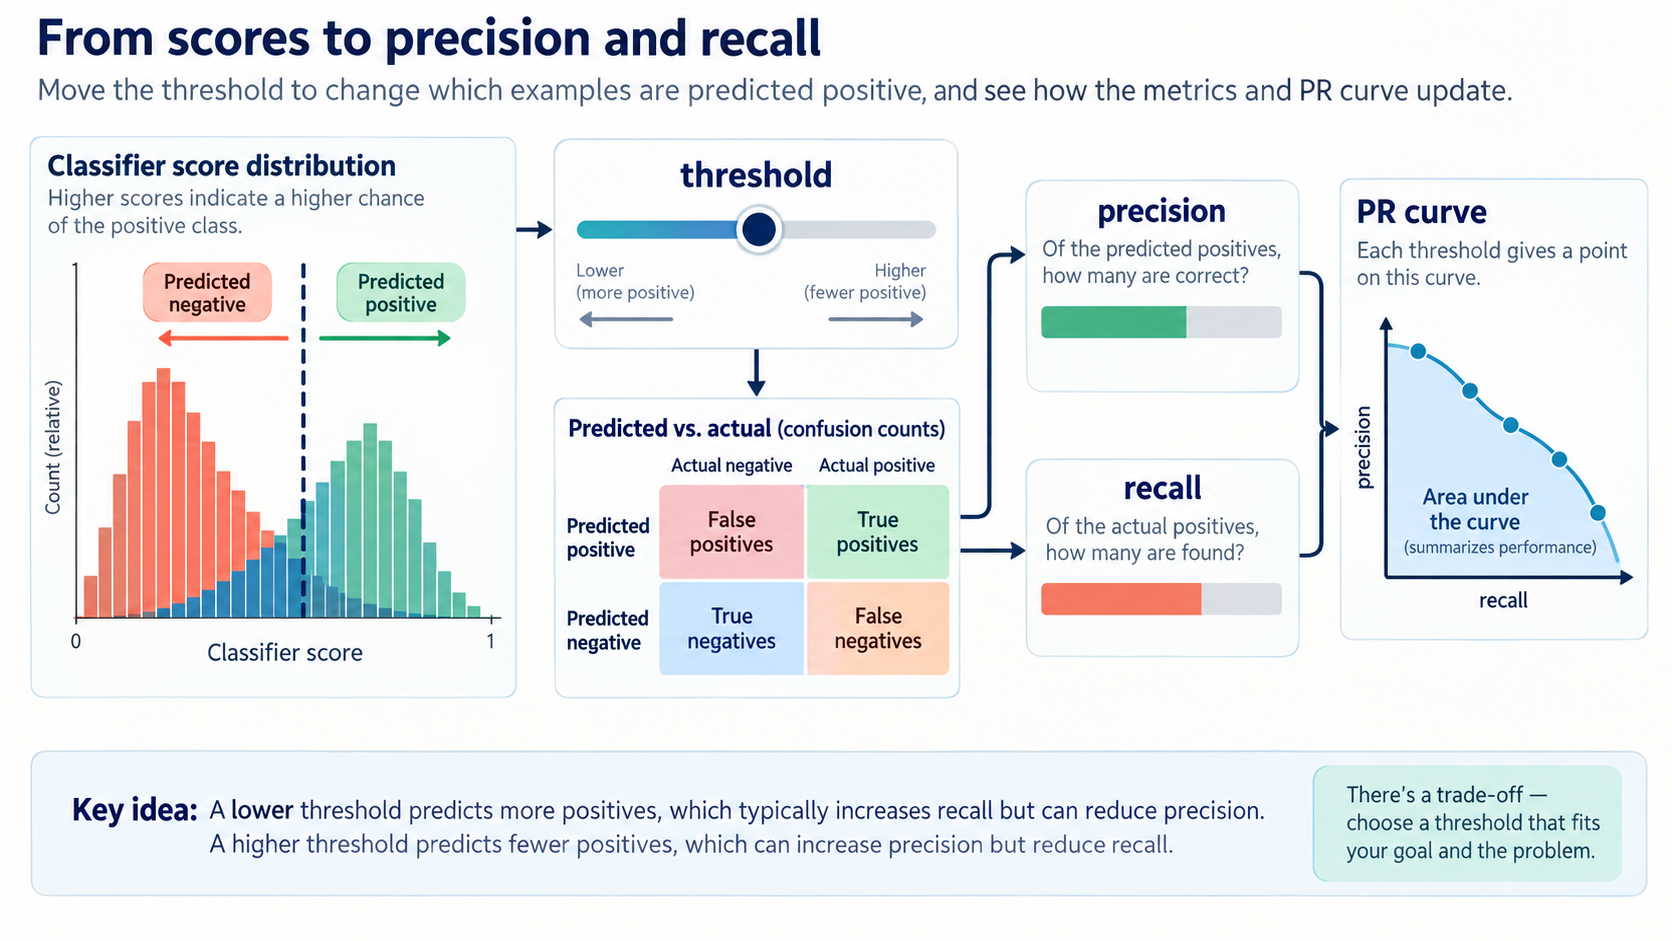

# F1 Score

Harmonic mean between precision and recall, where f1 score reaches its best value at 1 and worst at 0. The relative contribution of precision and recall to F1 is equal.

$F1 = \frac{2*TP}{2*TP+FP+FN}$

F1 is by default calulated as 0.0 when there are no true pos, false neg, or false pos.

In [74]:
from sklearn.metrics import f1_score
f1_score(y_test, (y_pred>=0.5).astype(int))

0.6389684813753582